# 02. Разведочный анализ данных (EDA)

**Цель:** исследовать датасет предложений для задачи определения границ предложений (sentence boundary detection). Понять структуру данных, распределения, edge-кейсы и сформулировать гипотезы для модели.

**Данные:** `data/processed/sentences.jsonl` — тексты из заданий ЕГЭ (sdamgia.ru)

**Формат записи:**
| Поле | Описание |
|------|----------|
| `id` | `text_{data_text_id}` |
| `source` | `reshuege_{task_id}` |
| `raw_text` | Текст с нумерацией `(1)...(2)...` |
| `clean_text` | Текст без номеров |
| `sentences` | Список `{idx, start, end, text}` |
| `num_sentences` | Количество предложений |

In [1]:
import json
import re
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

DATA_PATH = Path("../data/processed/sentences.jsonl")

## 1. Загрузка данных и базовая статистика

In [2]:
with open(DATA_PATH, encoding="utf-8") as f:
    dataset = [json.loads(line) for line in f]

print(f"Текстов: {len(dataset)}")
print(f"Предложений всего: {sum(r['num_sentences'] for r in dataset)}")

# Плоский DataFrame предложений для анализа
rows = []
for rec in dataset:
    for s in rec["sentences"]:
        rows.append({
            "text_id": rec["id"],
            "source": rec["source"],
            "sent_idx": s["idx"],
            "start": s["start"],
            "end": s["end"],
            "sent_text": s["text"],
            "sent_len": len(s["text"]),
            "clean_text_len": len(rec["clean_text"]),
            "num_sentences": rec["num_sentences"],
        })

df = pd.DataFrame(rows)
print(f"\nDataFrame: {df.shape[0]} строк x {df.shape[1]} столбцов")
df.head()

Текстов: 90
Предложений всего: 4359

DataFrame: 4359 строк x 9 столбцов


,text_id,source,sent_idx,start,end,sent_text,sent_len,clean_text_len,num_sentences
0,text_477,reshuege_10365,1,0,28,Сегодня я увидела ребёнка...,28,3045,30
1,text_477,reshuege_10365,2,29,143,"Многие говорят, что дети сегодня стали другие,...",114,3045,30
2,text_477,reshuege_10365,3,144,225,"И ещё говорят, что теперь дети более «смышлёны...",81,3045,30
3,text_477,reshuege_10365,4,226,372,"Взрослые радуются их вопросам не к месту, а по...",146,3045,30
4,text_477,reshuege_10365,5,373,446,"Именно поэтому ребёнок, которого я сегодня уви...",73,3045,30


In [3]:
text_stats = (
    df.groupby("text_id")
    .agg(
        num_sentences=("sent_idx", "count"),
        clean_text_len=("clean_text_len", "first"),
        avg_sent_len=("sent_len", "mean"),
        min_sent_len=("sent_len", "min"),
        max_sent_len=("sent_len", "max"),
    )
    .reset_index()
)

print("=== Статистика по текстам ===")
text_stats[["num_sentences", "clean_text_len", "avg_sent_len"]].describe().round(1)

=== Статистика по текстам ===


,num_sentences,clean_text_len,avg_sent_len
count,90.0,90.0,90.0
mean,48.4,3663.7,81.2
std,17.0,739.4,25.8
min,18.0,2006.0,40.0
25%,35.2,3083.8,63.6
50%,45.5,3557.5,76.8
75%,58.5,4171.5,93.6
max,97.0,5476.0,161.2


## 2. Распределения

### 2.1 Количество предложений на текст

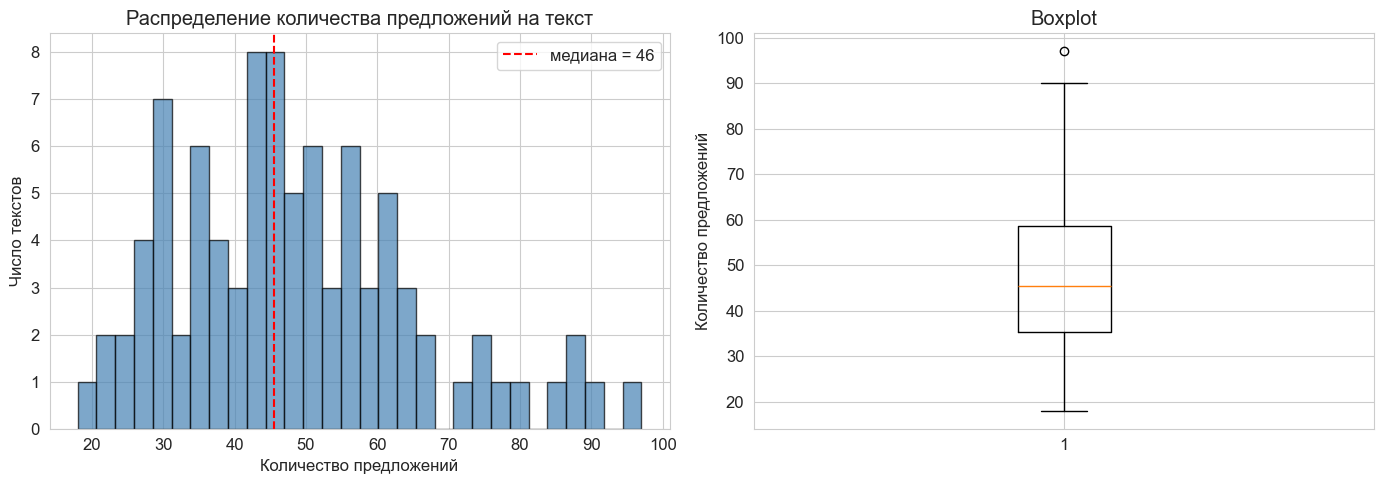


Текстов с ≤5 предложениями: 0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(text_stats["num_sentences"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(text_stats["num_sentences"].median(), color="red", ls="--",
                label=f'медиана = {text_stats["num_sentences"].median():.0f}')
axes[0].set_xlabel("Количество предложений")
axes[0].set_ylabel("Число текстов")
axes[0].set_title("Распределение количества предложений на текст")
axes[0].legend()

axes[1].boxplot(text_stats["num_sentences"], vert=True)
axes[1].set_ylabel("Количество предложений")
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

# Тексты с малым числом предложений — возможные проблемы парсинга
few_sents = text_stats[text_stats["num_sentences"] <= 5].sort_values("num_sentences")
print(f"\nТекстов с ≤5 предложениями: {len(few_sents)}")
for _, row in few_sents.iterrows():
    print(f"  {row['text_id']}: {row['num_sentences']} предл., длина текста {row['clean_text_len']} символов")

### 2.2 Длина текстов (в символах)

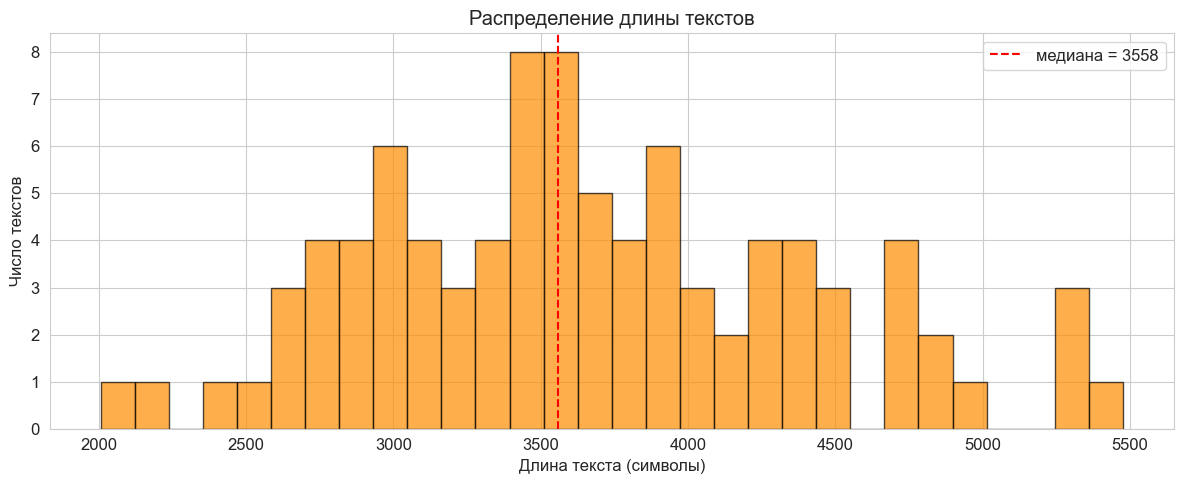

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(text_stats["clean_text_len"], bins=30, edgecolor="black", alpha=0.7, color="darkorange")
ax.axvline(text_stats["clean_text_len"].median(), color="red", ls="--",
           label=f'медиана = {text_stats["clean_text_len"].median():.0f}')
ax.set_xlabel("Длина текста (символы)")
ax.set_ylabel("Число текстов")
ax.set_title("Распределение длины текстов")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Длина предложений

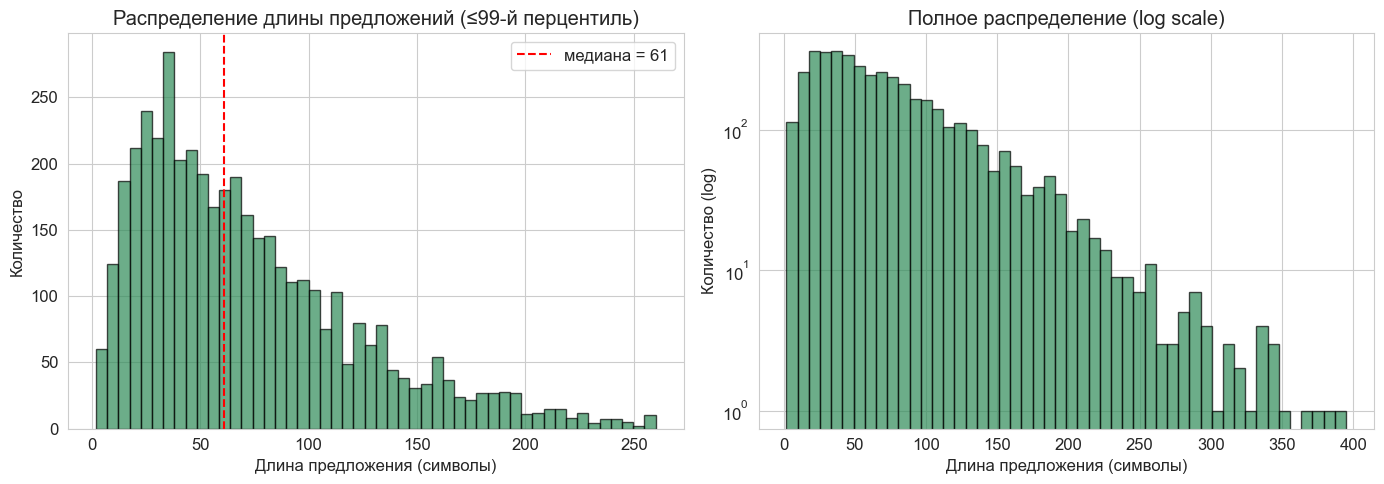

Перцентили длины предложений:
    5%: 13 символов
   25%: 34 символов
   50%: 61 символов
   75%: 101 символов
   90%: 150 символов
   95%: 184 символов
   99%: 260 символов


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма (обрезка по 99-му перцентилю для читаемости)
p99 = df["sent_len"].quantile(0.99)
axes[0].hist(df["sent_len"][df["sent_len"] <= p99], bins=50, edgecolor="black", alpha=0.7, color="seagreen")
axes[0].axvline(df["sent_len"].median(), color="red", ls="--",
                label=f'медиана = {df["sent_len"].median():.0f}')
axes[0].set_xlabel("Длина предложения (символы)")
axes[0].set_ylabel("Количество")
axes[0].set_title("Распределение длины предложений (≤99-й перцентиль)")
axes[0].legend()

# Log-scale для полного распределения
axes[1].hist(df["sent_len"], bins=50, edgecolor="black", alpha=0.7, color="seagreen")
axes[1].set_yscale("log")
axes[1].set_xlabel("Длина предложения (символы)")
axes[1].set_ylabel("Количество (log)")
axes[1].set_title("Полное распределение (log scale)")

plt.tight_layout()
plt.show()

print("Перцентили длины предложений:")
for p in [5, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:3d}%: {df['sent_len'].quantile(p / 100):.0f} символов")

In [7]:
print("=== Самые короткие предложения (≤10 символов) ===")
short = df[df["sent_len"] <= 10].sort_values("sent_len")
for _, row in short.iterrows():
    print(f"  [{row['text_id']}] ({row['sent_idx']}) len={row['sent_len']} {repr(row['sent_text'])}")

print(f"\n=== Самые длинные предложения (>500 символов) ===")
long_ = df[df["sent_len"] > 500].sort_values("sent_len", ascending=False)
print(f"Таких предложений: {len(long_)}")
for _, row in long_.head(5).iterrows():
    print(f"  [{row['text_id']}] ({row['sent_idx']}) len={row['sent_len']} {row['sent_text'][:100]}...")

=== Самые короткие предложения (≤10 символов) ===
  [text_643] (10) len=2 'А?'
  [text_730] (52) len=3 'Да!'
  [text_643] (7) len=3 'Уф!'
  [text_315] (35) len=3 'Да.'
  [text_730] (51) len=3 'Да!'
  [text_315] (56) len=4 'Как?'
  [text_833] (40) len=4 'Рус!'
  [text_315] (27) len=4 'Сел.'
  [text_798] (17) len=4 'Дом?'
  [text_760] (33) len=5 'Где?!'
  [text_758] (43) len=5 'Стар.'
  [text_318] (31) len=5 'Тихо!'
  [text_320] (16) len=5 'Мины!'
  [text_643] (32) len=5 'Да. —'
  [text_643] (29) len=5 'Да. —'
  [text_798] (67) len=5 'Вася!'
  [text_315] (36) len=5 'Нету!'
  [text_798] (54) len=5 'Ну! —'
  [text_840] (54) len=5 'Да...'
  [text_840] (66) len=5 'Буду.'
  [text_766] (27) len=5 'Пиши!'
  [text_462] (55) len=6 'Слышу!'
  [text_285] (21) len=6 'Царей!'
  [text_760] (32) len=6 'Эй ты!'
  [text_777] (8) len=6 'Зачем?'
  [text_776] (19) len=6 'Сидит…'
  [text_766] (15) len=6 'Верно?'
  [text_306] (1) len=6 'Будни.'
  [text_285] (28) len=6 '−Батя!'
  [text_737] (62) len=6 'Алёше.'

### 2.4 Связь длины текста и количества предложений

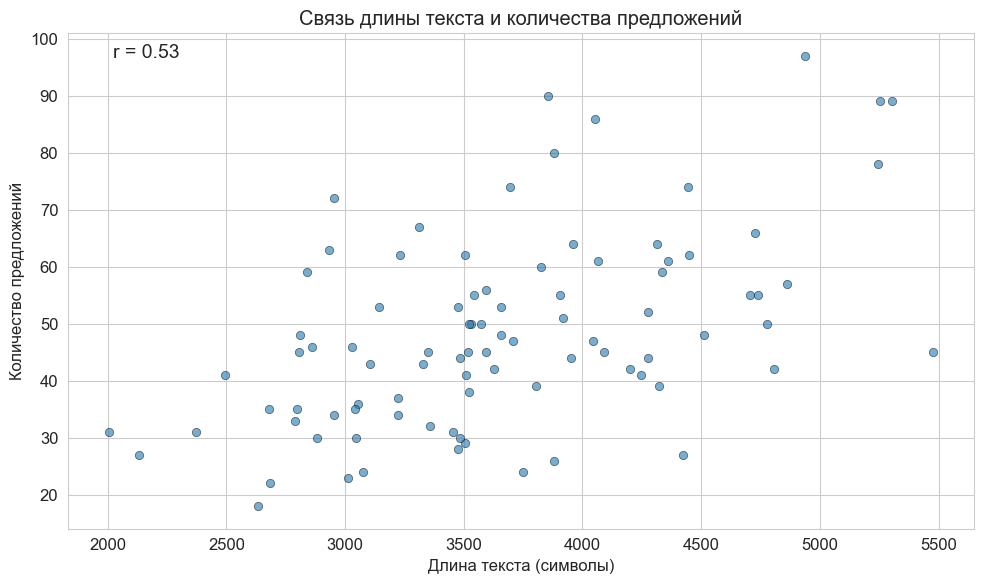

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(text_stats["clean_text_len"], text_stats["num_sentences"],
           alpha=0.6, edgecolors="black", linewidth=0.5)
ax.set_xlabel("Длина текста (символы)")
ax.set_ylabel("Количество предложений")
ax.set_title("Связь длины текста и количества предложений")

corr = text_stats["clean_text_len"].corr(text_stats["num_sentences"])
ax.annotate(f"r = {corr:.2f}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=14)

# Подсветка аномалий: мало предложений при длинном тексте
outliers = text_stats[(text_stats["num_sentences"] <= 5) & (text_stats["clean_text_len"] > 1000)]
for _, row in outliers.iterrows():
    ax.annotate(row["text_id"], (row["clean_text_len"], row["num_sentences"]),
                fontsize=8, color="red")

plt.tight_layout()
plt.show()

## 3. Анализ символов на границах предложений

Ключевой раздел для задачи sentence boundary detection. Какие символы встречаются на границах? Насколько надёжны простые правила (точка + пробел + заглавная)?

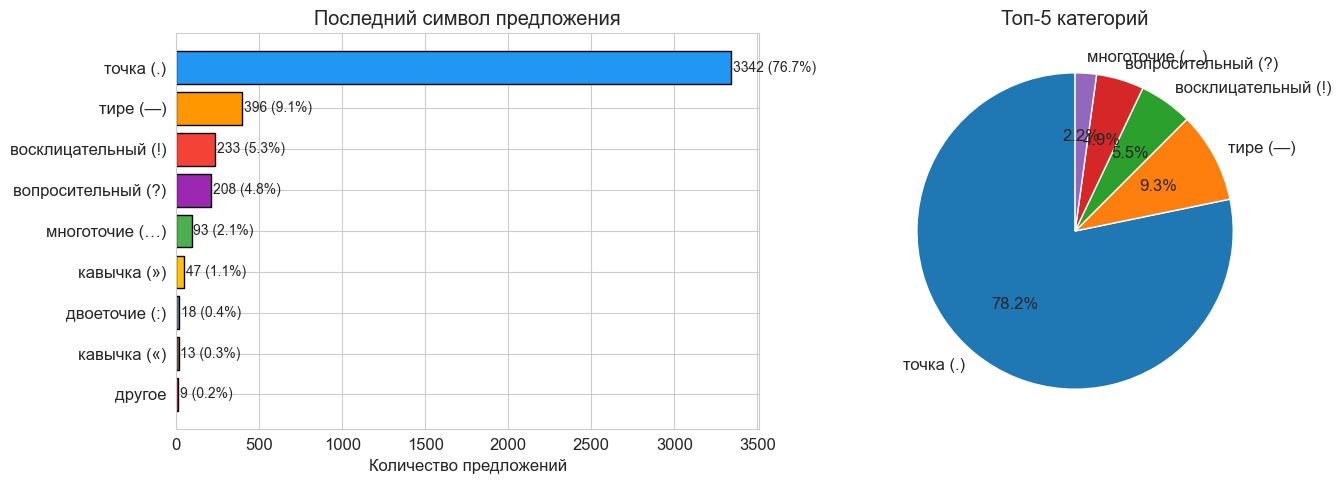

In [9]:
# Последний символ каждого предложения
end_chars = Counter()
for rec in dataset:
    for s in rec["sentences"]:
        t = s["text"].rstrip()
        if t:
            end_chars[t[-1]] += 1

total_sents = sum(end_chars.values())

# Категоризация
categories = Counter()
cat_map = {
    ".": "точка (.)", "?": "вопросительный (?)", "!": "восклицательный (!)",
    "\u2026": "многоточие (\u2026)", "\u00bb": "кавычка (\u00bb)", "\u00ab": "кавычка (\u00ab)",
    ":": "двоеточие (:)",
}
dash_chars = set("\u2014\u2013\u2212-")

for ch, cnt in end_chars.items():
    if ch in cat_map:
        categories[cat_map[ch]] += cnt
    elif ch in dash_chars:
        categories["тире (\u2014)"] += cnt
    else:
        categories["другое"] += cnt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats_sorted = sorted(categories.items(), key=lambda x: -x[1])
labels = [c[0] for c in cats_sorted]
values = [c[1] for c in cats_sorted]
colors = ["#2196F3", "#FF9800", "#f44336", "#9C27B0", "#4CAF50",
          "#FFC107", "#607D8B", "#795548", "#E91E63"]

axes[0].barh(labels[::-1], values[::-1],
             color=colors[:len(labels)][::-1], edgecolor="black")
axes[0].set_xlabel("Количество предложений")
axes[0].set_title("Последний символ предложения")
for i, v in enumerate(values[::-1]):
    axes[0].text(v + 10, i, f"{v} ({100 * v / total_sents:.1f}%)", va="center", fontsize=10)

top5 = cats_sorted[:5]
axes[1].pie([v for _, v in top5], labels=[l for l, _ in top5],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Топ-5 категорий")

plt.tight_layout()
plt.show()

### 3.1 Предложения с нестандартными окончаниями

Предложения, заканчивающиеся тире, кавычками или буквами — это диалоги и цитаты, где граница не совпадает с привычной пунктуацией.

In [10]:
print("=== Предложения, заканчивающиеся тире (\u2014) ===")
dash_endings = [(rec["id"], s["idx"], s["text"])
                for rec in dataset for s in rec["sentences"]
                if s["text"].rstrip()[-1:] in "\u2014\u2013\u2212-"]
for rid, idx, text in dash_endings[:8]:
    print(f"  [{rid}] ({idx}) ...{text[-80:]}")
print(f"Всего: {len(dash_endings)}")

print(f"\n=== Предложения, заканчивающиеся открывающей кавычкой (\u00ab) ===")
open_quote_endings = [(rec["id"], s["idx"], s["text"])
                      for rec in dataset for s in rec["sentences"]
                      if s["text"].rstrip().endswith("\u00ab")]
for rid, idx, text in open_quote_endings:
    print(f"  [{rid}] ({idx}) ...{text[-80:]}")
print(f"Всего: {len(open_quote_endings)}")

print(f"\n=== Предложения без финальной пунктуации (заканчиваются буквой) ===")
letter_endings = [(rec["id"], s["idx"], s["text"])
                  for rec in dataset for s in rec["sentences"]
                  if s["text"].rstrip() and s["text"].rstrip()[-1].isalpha()]
for rid, idx, text in letter_endings[:10]:
    print(f"  [{rid}] ({idx}) ...{text[-80:]}")
print(f"Всего: {len(letter_endings)}")

=== Предложения, заканчивающиеся тире (—) ===
  [text_601] (4) ...Через всё море, словно след от удара бичом, тянулась красная дрожащая полоса. —
  [text_601] (5) ...Вредное зрелище — закат, — сказал Максимов. —
  [text_601] (6) ...А по-моему, прекрасное, —ответил Саша Зеленин. —
  [text_601] (10) ...Но на самом-то деле её нет. —
  [text_601] (14) ...Это был Тёплый берег, где в этот час тысячи людей готовили ужин. —
  [text_601] (16) ...Рядом вынырнул Сашка с вытаращенными глазами и открытым ртом. —
  [text_601] (18) ...Они вернулись к молу и уселись на железной лестнице. —
  [text_601] (20) ...Саша вздохнул: —
Всего: 396

=== Предложения, заканчивающиеся открывающей кавычкой («) ===
  [text_477] (13) ...Но родители ответили ему лишь улыбкой и шутками. «
  [text_484] (12) ...Виктор Петрович с улыбкой ответил: «
  [text_492] (11) ...Я поздоровался с ней, тогда она засмеялась и сказала: «
  [text_616] (22) ...И вот он шёл и смотрел, как за лесом спускаются белые парашюты. «
  [text_619] 

### 3.2 Биграммы на границах: (последний символ, первый символ следующего)

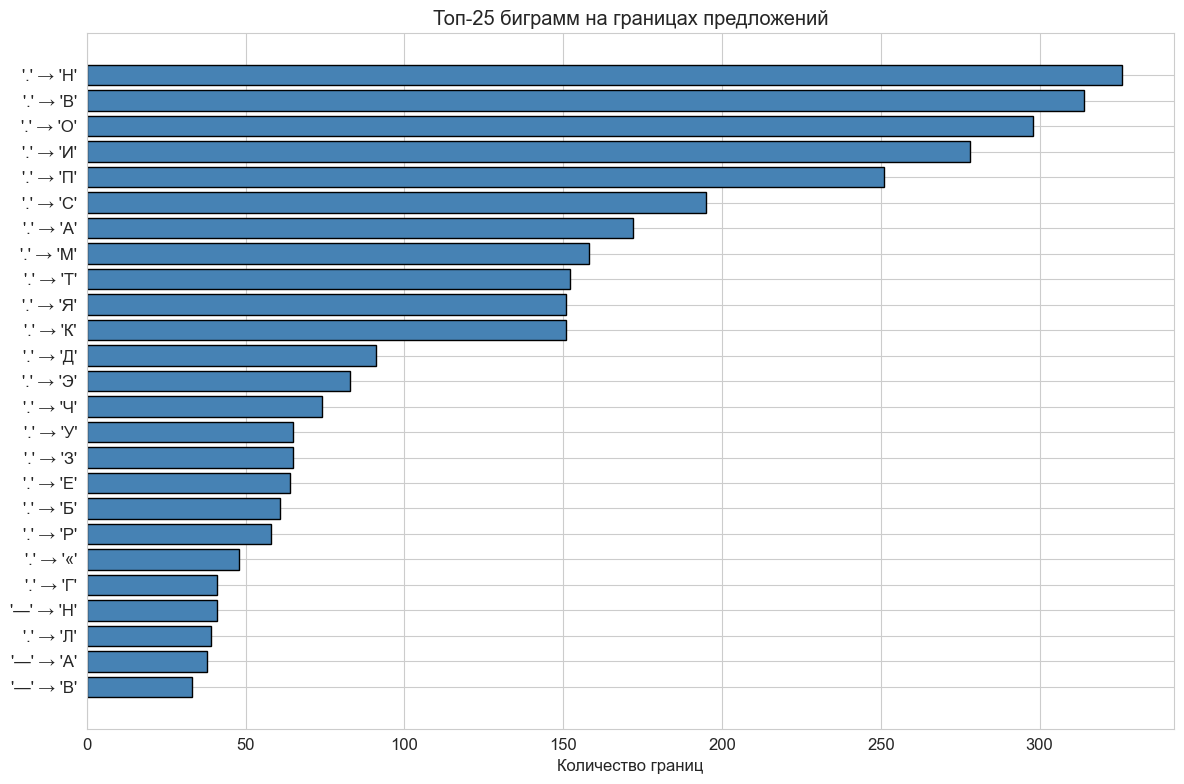

Стандартные границы (пунктуация + заглавная): 3677/4269 (86.1%)
Нестандартные границы: 592 (13.9%)


In [11]:
boundary_bigrams = Counter()
for rec in dataset:
    sents = rec["sentences"]
    for i in range(len(sents) - 1):
        s1_text = sents[i]["text"]
        s2_text = sents[i + 1]["text"]
        if s1_text and s2_text:
            boundary_bigrams[(s1_text[-1], s2_text[0])] += 1

top_bigrams = boundary_bigrams.most_common(25)
labels_bg = [f"{repr(c1)} \u2192 {repr(c2)}" for (c1, c2), _ in top_bigrams]
counts_bg = [cnt for _, cnt in top_bigrams]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(labels_bg[::-1], counts_bg[::-1], color="steelblue", edgecolor="black")
ax.set_xlabel("Количество границ")
ax.set_title("Топ-25 биграмм на границах предложений")
plt.tight_layout()
plt.show()

# Стандартные vs нестандартные границы
total_boundaries = sum(boundary_bigrams.values())
standard = sum(cnt for (c1, c2), cnt in boundary_bigrams.items()
               if c1 in ".!?\u2026" and c2.isupper())
print(f"Стандартные границы (пунктуация + заглавная): {standard}/{total_boundaries} ({100 * standard / total_boundaries:.1f}%)")
print(f"Нестандартные границы: {total_boundaries - standard} ({100 * (total_boundaries - standard) / total_boundaries:.1f}%)")

## 4. Точки в тексте: границы vs. не-границы

Для модели критически важно отличать точки-границы от точек внутри предложений (сокращения, инициалы, числа, многоточия из трёх точек).

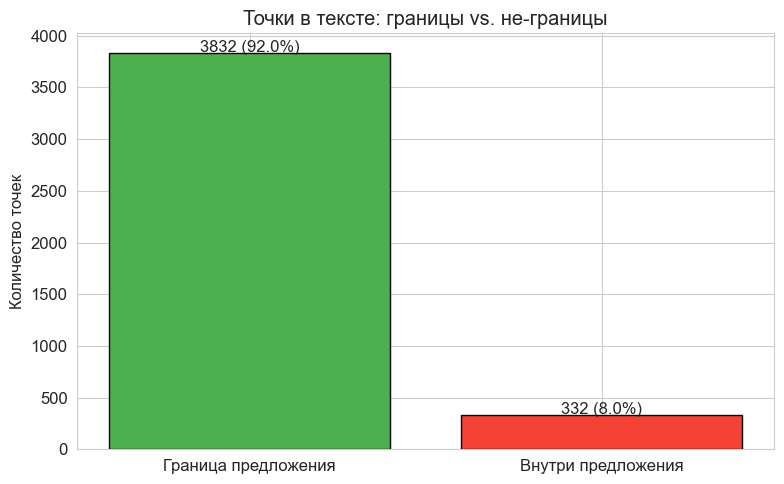


8.0% точек НЕ являются границами предложений!

Примеры точек внутри предложений:
  ...и лучших времён....
  ...ругом письме: «...даже кувалда...
  ...угом письме: «...даже кувалда,...
  ...гом письме: «...даже кувалда, ...
  ...ь и очень важно....
  ...го и вам желаем....
  ...ос нашей сказки....
  ...икулы, прощайте... — Да не езд...
  ...кулы, прощайте... — Да не езди...
  ...ать четыре года....
  ...т себя одиноким....
  ...дуновение весны....
  ... путешественник....
  ... глагола «ЕСТЬ»....
  ...го возможностей....


In [12]:
boundary_dots = 0
non_boundary_dots = 0
non_boundary_examples = []

for rec in dataset:
    ct = rec["clean_text"]
    sents = rec["sentences"]

    # Позиции концов предложений (кроме последнего) — истинные границы
    boundary_ends = set()
    for i in range(len(sents) - 1):
        boundary_ends.add(sents[i]["end"])

    for pos, ch in enumerate(ct):
        if ch != ".":
            continue
        # Точка на позиции pos является частью границы, если pos+1 близок к s["end"]
        is_boundary = any(abs(pos + 1 - be) <= 2 for be in boundary_ends)
        if is_boundary:
            boundary_dots += 1
        else:
            non_boundary_dots += 1
            if len(non_boundary_examples) < 30:
                context = ct[max(0, pos - 15):pos + 15]
                non_boundary_examples.append(context)

total_dots = boundary_dots + non_boundary_dots

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Граница предложения", "Внутри предложения"],
              [boundary_dots, non_boundary_dots],
              color=["#4CAF50", "#f44336"], edgecolor="black")
ax.set_ylabel("Количество точек")
ax.set_title("Точки в тексте: границы vs. не-границы")
for bar, val in zip(bars, [boundary_dots, non_boundary_dots]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{val} ({100 * val / total_dots:.1f}%)", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n{100 * non_boundary_dots / total_dots:.1f}% точек НЕ являются границами предложений!")
print(f"\nПримеры точек внутри предложений:")
for ex in non_boundary_examples[:15]:
    print(f"  ...{ex}...")

### 4.1 Контекст вокруг точек: граница vs. не-граница

In [13]:
# Паттерны: char_before + "." + char_after для boundary vs non-boundary
boundary_patterns = Counter()
non_boundary_patterns = Counter()

for rec in dataset:
    ct = rec["clean_text"]
    sents = rec["sentences"]
    boundary_ends = set()
    for i in range(len(sents) - 1):
        boundary_ends.add(sents[i]["end"])

    for pos, ch in enumerate(ct):
        if ch != ".":
            continue
        before = ct[pos - 1] if pos > 0 else "^"
        after = ct[pos + 1] if pos + 1 < len(ct) else "$"
        pattern = f"{before}.{after}"

        is_boundary = any(abs(pos + 1 - be) <= 2 for be in boundary_ends)
        if is_boundary:
            boundary_patterns[pattern] += 1
        else:
            non_boundary_patterns[pattern] += 1

print("=== Паттерны точек-ГРАНИЦ (топ-15) ===")
for pat, cnt in boundary_patterns.most_common(15):
    print(f"  {repr(pat):12s}  {cnt:4d}")

print("\n=== Паттерны точек-НЕ-ГРАНИЦ (топ-15) ===")
for pat, cnt in non_boundary_patterns.most_common(15):
    print(f"  {repr(pat):12s}  {cnt:4d}")

# Точка + пробел + регистр следующего символа
p_space_upper = sum(1 for rec in dataset
                    for i in range(len(rec["clean_text"]) - 2)
                    if rec["clean_text"][i] == "."
                    and rec["clean_text"][i + 1] == " "
                    and rec["clean_text"][i + 2].isupper())
p_space_lower = sum(1 for rec in dataset
                    for i in range(len(rec["clean_text"]) - 2)
                    if rec["clean_text"][i] == "."
                    and rec["clean_text"][i + 1] == " "
                    and rec["clean_text"][i + 2].islower())
print(f"\n=== Точка + пробел + следующий символ ===")
print(f"  Точка + пробел + ЗАГЛАВНАЯ: {p_space_upper}")
print(f"  Точка + пробел + строчная:  {p_space_lower}")
if p_space_upper + p_space_lower > 0:
    print(f"  {100 * p_space_lower / (p_space_upper + p_space_lower):.1f}% — строчная (скорее всего НЕ граница)")

=== Паттерны точек-ГРАНИЦ (топ-15) ===
  'а. '          391
  'и. '          363
  'е. '          300
  'о. '          256
  'я. '          255
  'ь. '          250
  'м. '          209
  'у. '          191
  'й. '          164
  'т. '          154
  'ы. '          141
  '.. '          131
  '...'          116
  'н. '          102
  'в. '           90

=== Паттерны точек-НЕ-ГРАНИЦ (топ-15) ===
  '...'           47
  '.. '           32
  '). '           17
  '7. '           14
  'т. '           10
  'е..'            9
  'я.$'            9
  'а..'            9
  'е.$'            8
  'ь.$'            8
  'е. '            8
  'и. '            8
  'м.$'            7
  'и.$'            7
  'о..'            7

=== Точка + пробел + следующий символ ===
  Точка + пробел + ЗАГЛАВНАЯ: 3265
  Точка + пробел + строчная:  26
  0.8% — строчная (скорее всего НЕ граница)


## 5. Диалоги и прямая речь

Предложения с прямой речью — одна из главных сложностей. Границы внутри диалогов часто нестандартные: тире, открывающие/закрывающие кавычки, граница посередине реплики.

In [14]:
texts_with_dialogue = set()
dialogue_boundaries = 0
total_bd = 0

for rec in dataset:
    sents = rec["sentences"]
    for i in range(len(sents) - 1):
        total_bd += 1
        s1 = sents[i]["text"]
        s2 = sents[i + 1]["text"]

        is_dialogue = (
            s1.rstrip().endswith("\u2014") or
            s1.rstrip().endswith("\u00ab") or
            s2.lstrip().startswith("\u2014") or
            (s1.count("\u00ab") > s1.count("\u00bb"))  # незакрытая кавычка
        )
        if is_dialogue:
            dialogue_boundaries += 1
            texts_with_dialogue.add(rec["id"])

print(f"Текстов с диалогами/прямой речью: {len(texts_with_dialogue)} из {len(dataset)}")
print(f"Границ внутри диалогов: {dialogue_boundaries} из {total_bd} ({100 * dialogue_boundaries / total_bd:.1f}%)")

# Баланс кавычек
balanced = unbalanced_open = unbalanced_close = 0
for rec in dataset:
    for s in rec["sentences"]:
        opens = s["text"].count("\u00ab")
        closes = s["text"].count("\u00bb")
        if opens == closes:
            balanced += 1
        elif opens > closes:
            unbalanced_open += 1
        else:
            unbalanced_close += 1

print(f"\n=== Баланс кавычек \u00ab...\u00bb в предложениях ===")
print(f"  Сбалансированные: {balanced}")
print(f"  Больше \u00ab (открытых): {unbalanced_open}")
print(f"  Больше \u00bb (закрытых): {unbalanced_close}")
print(f"\n  Несбалансированные кавычки = граница проходит внутри цитаты")

Текстов с диалогами/прямой речью: 52 из 90
Границ внутри диалогов: 413 из 4269 (9.7%)

=== Баланс кавычек «...» в предложениях ===
  Сбалансированные: 4277
  Больше « (открытых): 41
  Больше » (закрытых): 41

  Несбалансированные кавычки = граница проходит внутри цитаты


## 6. Качество данных

### 6.1 Проверка позиций: `clean_text[start:end] == text`

In [15]:
position_errors = []
for rec in dataset:
    ct = rec["clean_text"]
    for s in rec["sentences"]:
        actual = ct[s["start"]:s["end"]]
        if actual != s["text"]:
            position_errors.append({
                "text_id": rec["id"],
                "sent_idx": s["idx"],
                "expected": s["text"][:50],
                "actual": actual[:50],
            })

print(f"Ошибок позиций: {len(position_errors)} из {len(df)} предложений")
if position_errors:
    for err in position_errors[:5]:
        print(f"  [{err['text_id']}] ({err['sent_idx']})")
        print(f"    Ожидалось: {err['expected']}...")
        print(f"    Получено:  {err['actual']}...")

Ошибок позиций: 0 из 4359 предложений


### 6.2 Покрытие текста предложениями

In [16]:
coverage_stats = []
for rec in dataset:
    ct_len = len(rec["clean_text"])
    sents = rec["sentences"]
    covered = sum(s["end"] - s["start"] for s in sents)
    first_start = sents[0]["start"]
    last_end = sents[-1]["end"]
    coverage_stats.append({
        "text_id": rec["id"],
        "ct_len": ct_len,
        "covered": covered,
        "coverage_pct": 100 * covered / ct_len if ct_len > 0 else 0,
        "starts_at_0": first_start == 0,
        "ends_at_ct_len": last_end == ct_len,
        "gap_at_end": ct_len - last_end,
    })

cov_df = pd.DataFrame(coverage_stats)
print(f"Среднее покрытие текста предложениями: {cov_df['coverage_pct'].mean():.1f}%")
print(f"Текстов, где первое предложение начинается не с 0: {(~cov_df['starts_at_0']).sum()}")
print(f"Текстов, где последнее предложение не доходит до конца: {(~cov_df['ends_at_ct_len']).sum()}")

gaps = cov_df[cov_df["gap_at_end"] > 10].sort_values("gap_at_end", ascending=False)
if len(gaps) > 0:
    print(f"\nТекстов с непокрытым хвостом (>10 символов): {len(gaps)}")
    for _, row in gaps.head(5).iterrows():
        rec = next(r for r in dataset if r["id"] == row["text_id"])
        tail = rec["clean_text"][rec["sentences"][-1]["end"]:]
        print(f"  {row['text_id']}: {row['gap_at_end']} симв. | {tail[:80]}...")

Среднее покрытие текста предложениями: 98.5%
Текстов, где первое предложение начинается не с 0: 19
Текстов, где последнее предложение не доходит до конца: 0


### 6.3 Перекрытия и промежутки между предложениями

In [17]:
overlaps = []
non_space_gaps = []

for rec in dataset:
    ct = rec["clean_text"]
    sents = rec["sentences"]
    for i in range(len(sents) - 1):
        s1, s2 = sents[i], sents[i + 1]

        if s1["end"] > s2["start"]:
            overlaps.append({
                "text_id": rec["id"],
                "sent_i": s1["idx"], "sent_j": s2["idx"],
                "overlap": s1["end"] - s2["start"],
            })

        gap_text = ct[s1["end"]:s2["start"]]
        if gap_text and gap_text.strip():
            non_space_gaps.append({
                "text_id": rec["id"],
                "sent_i": s1["idx"], "sent_j": s2["idx"],
                "gap_text": gap_text[:100],
            })

print(f"Перекрывающихся пар предложений: {len(overlaps)}")
for ov in overlaps[:10]:
    print(f"  {ov['text_id']}: предложения {ov['sent_i']}\u2192{ov['sent_j']}, перекрытие {ov['overlap']} символов")

print(f"\nПар с непустым промежутком (не только пробел): {len(non_space_gaps)}")
for g in non_space_gaps[:5]:
    print(f"  {g['text_id']}: ({g['sent_i']}\u2192{g['sent_j']}) gap: {repr(g['gap_text'][:60])}")

Перекрывающихся пар предложений: 0

Пар с непустым промежутком (не только пробел): 0


### 6.4 Непоследовательные индексы предложений

Если индексы идут не по порядку (1, 2, 3...) или с пропусками — ошибка в разметке на сайте-источнике.

In [18]:
bad_idx_texts = []
for rec in dataset:
    indices = [s["idx"] for s in rec["sentences"]]
    expected = list(range(indices[0], indices[0] + len(indices)))
    if indices != expected:
        bad_idx_texts.append({
            "text_id": rec["id"],
            "indices": indices,
            "num_sentences": rec["num_sentences"],
            "clean_text_len": len(rec["clean_text"]),
        })

print(f"Текстов с непоследовательными индексами: {len(bad_idx_texts)}")
for t in bad_idx_texts:
    idx_str = str(t["indices"][:10])
    if len(t["indices"]) > 10:
        idx_str += "..."
    print(f"  {t['text_id']}: num_sentences={t['num_sentences']}, "
          f"len={t['clean_text_len']}, idx={idx_str}")
    print(f"    РЕКОМЕНДАЦИЯ: исключить из обучающей выборки")

Текстов с непоследовательными индексами: 2
  text_833: num_sentences=46, len=3028, idx=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
    РЕКОМЕНДАЦИЯ: исключить из обучающей выборки
  text_843: num_sentences=89, len=5302, idx=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
    РЕКОМЕНДАЦИЯ: исключить из обучающей выборки


### 6.5 Предложения с непарсенными маркерами `(N)` внутри

In [19]:
problem_texts = []
for rec in dataset:
    for s in rec["sentences"]:
        internal_markers = re.findall(r"\(\d+\)", s["text"])
        if internal_markers:
            problem_texts.append({
                "text_id": rec["id"],
                "sent_idx": s["idx"],
                "sent_len": len(s["text"]),
                "internal_markers": len(internal_markers),
                "example": s["text"][:120],
            })

if problem_texts:
    prob_df = pd.DataFrame(problem_texts)
    affected_texts = prob_df["text_id"].nunique()
    print(f"Предложений с непарсенными маркерами (N) внутри: {len(prob_df)}")
    print(f"Затронутых текстов: {affected_texts} из {len(dataset)}")
    for _, row in prob_df.head(5).iterrows():
        print(f"\n  [{row['text_id']}] ({row['sent_idx']}) len={row['sent_len']}, маркеров: {row['internal_markers']}")
        print(f"    {row['example']}...")
    print(f"\n  РЕКОМЕНДАЦИЯ: эти {affected_texts} текстов следует исключить или перепарсить")
else:
    print("Все предложения без внутренних маркеров — OK")

# Сводка проблемных текстов
problem_ids = set()
for t in bad_idx_texts:
    problem_ids.add(t["text_id"])
if problem_texts:
    for t in problem_texts:
        problem_ids.add(t["text_id"])
for ov in overlaps:
    problem_ids.add(ov["text_id"])

print(f"\n=== Итого проблемных текстов: {len(problem_ids)} из {len(dataset)} ===")
print(f"  ID: {sorted(problem_ids)}")
print(f"  Чистых текстов для обучения: {len(dataset) - len(problem_ids)}")

Все предложения без внутренних маркеров — OK

=== Итого проблемных текстов: 2 из 90 ===
  ID: ['text_833', 'text_843']
  Чистых текстов для обучения: 88


## 7. Контекст вокруг границ: признаки для модели

### 7.1 Тепловая карта типов символов вокруг границ

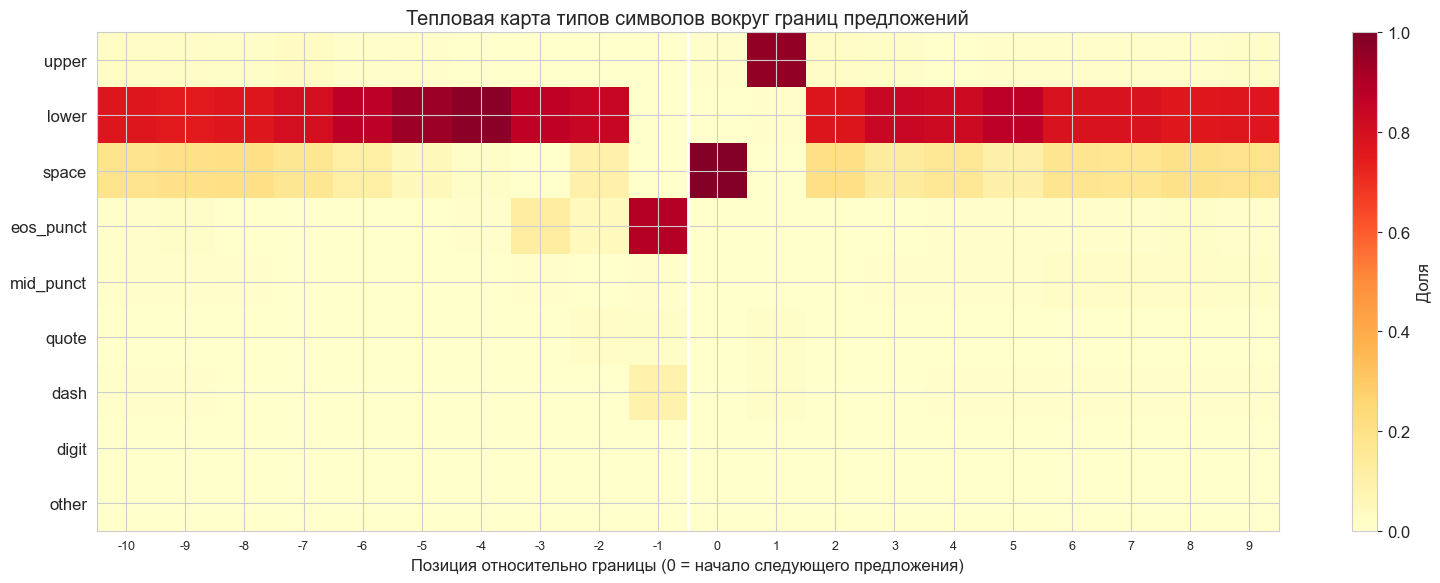

In [20]:
WINDOW = 10

# Собираем окна вокруг каждой границы
boundary_windows = []
for rec in dataset:
    ct = rec["clean_text"]
    sents = rec["sentences"]
    for i in range(len(sents) - 1):
        bp = sents[i]["end"]
        before = ct[max(0, bp - WINDOW):bp]
        after = ct[bp:min(len(ct), bp + WINDOW)]
        boundary_windows.append({"before": before, "after": after})

def char_type(ch):
    if ch.isupper(): return "upper"
    if ch.islower(): return "lower"
    if ch.isdigit(): return "digit"
    if ch == " ": return "space"
    if ch in ".!?\u2026": return "eos_punct"
    if ch in ",;:": return "mid_punct"
    if ch in "\u00ab\u00bb\u201e\u201c\"'": return "quote"
    if ch in "\u2014\u2013\u2212-": return "dash"
    return "other"

# Частота каждого типа на каждой позиции
all_types = ["upper", "lower", "space", "eos_punct", "mid_punct", "quote", "dash", "digit", "other"]
positions = list(range(-WINDOW, WINDOW))
char_counts = {pos: Counter() for pos in positions}

for w in boundary_windows:
    for i, ch in enumerate(w["before"]):
        pos = i - len(w["before"])
        char_counts[pos][char_type(ch)] += 1
    for i, ch in enumerate(w["after"]):
        char_counts[i][char_type(ch)] += 1

matrix = np.zeros((len(all_types), len(positions)))
for j, pos in enumerate(positions):
    total = sum(char_counts[pos].values()) or 1
    for i, ct_ in enumerate(all_types):
        matrix[i, j] = char_counts[pos].get(ct_, 0) / total

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(positions)))
ax.set_xticklabels(positions, fontsize=9)
ax.set_yticks(range(len(all_types)))
ax.set_yticklabels(all_types)
ax.set_xlabel("Позиция относительно границы (0 = начало следующего предложения)")
ax.set_title("Тепловая карта типов символов вокруг границ предложений")
ax.axvline(WINDOW - 0.5, color="white", linewidth=2)
plt.colorbar(im, ax=ax, label="Доля")
plt.tight_layout()
plt.show()

### 7.2 Примеры окон: точка-граница vs точка-не-граница

In [21]:
true_windows = []
false_windows = []

for rec in dataset:
    ct = rec["clean_text"]
    sents = rec["sentences"]
    boundary_ends = set()
    for i in range(len(sents) - 1):
        boundary_ends.add(sents[i]["end"])

    for pos, ch in enumerate(ct):
        if ch != ".":
            continue
        before = ct[max(0, pos - 4):pos + 1]
        after = ct[pos + 1:min(len(ct), pos + 6)]
        window = before + "|" + after

        is_boundary = any(abs(pos + 1 - be) <= 2 for be in boundary_ends)
        if is_boundary:
            true_windows.append(window)
        else:
            false_windows.append(window)

random.seed(42)

print(f"Окна вокруг точек-границ: {len(true_windows)}")
print(f"Окна вокруг точек-не-границ: {len(false_windows)}")

print("\n=== Примеры: точка-ГРАНИЦА ===")
for w in random.sample(true_windows, min(10, len(true_windows))):
    print(f"  {w}")

print("\n=== Примеры: точка-НЕ-ГРАНИЦА ===")
for w in random.sample(false_windows, min(10, len(false_windows))):
    print(f"  {w}")

Окна вокруг точек-границ: 3832
Окна вокруг точек-не-границ: 332

=== Примеры: точка-ГРАНИЦА ===
  ряк».| В не
  крой.|.. Ма
  зкою.| И бл
  блей.| Я по
  анно.| Ещё 
  сиям.| А мн
  сить.| Вот 
  цену.| А да
  мину.| Ладо
  я»...| И он

=== Примеры: точка-НЕ-ГРАНИЦА ===
  иус).| Кот 
  вичу.|..» «
  ак...| ну, 
  ть...| — по
  вижу.|..» К
   нет.|
  вижу.|
  ябко.|.. — 
  ано..|. – б
   Нет.| Драк


## 8. Итоги и рекомендации

### Ключевые наблюдения

1. **Большинство предложений заканчиваются точкой**, но значительная доля всех точек в тексте НЕ являются границами (сокращения, инициалы, многоточия) — модель не может просто «ставить границу после каждой точки»

2. **Большинство границ стандартные** (пунктуация + пробел + заглавная), но ~10% нестандартные (тире, открытые кавычки) — это сложные случаи для модели

3. **Диалоги и прямая речь** (52 из 90 текстов) — основной источник сложности: 396 предложений заканчиваются тире, 13 — открывающей кавычкой

4. **Качество данных отличное:** 0 ошибок позиций, 0 перекрытий, 0 непарсенных маркеров. Только 2 текста с непоследовательными индексами (ошибки разметки на сайте-источнике) — исключить перед обучением

### Потенциальные признаки для модели

| Признак | Описание | Обоснование |
|---------|----------|-------------|
| `char` | Текущий символ | Пробел между предложениями |
| `prev_chars`, `next_chars` | Соседние символы в окне ±5-10 | Контекст границы |
| `is_eos_punct[-3:-1]` | Есть ли `.!?…` в окне | Финальная пунктуация |
| `next_is_upper` | Следующий не-пробел — заглавная | Начало предложения |
| `quote_balance` | Баланс `«/»` в окне | Граница внутри цитаты |
| `dash_nearby` | Тире в окне | Диалоговые границы |
| `distance_since_last_eos` | Символов с последней `.!?…` | Длина текущего предложения |
| `position_in_text` | Относительная позиция (0-1) | Структура текста |

### Рекомендации

- **Фильтрация:** исключить 2 проблемных текста (text_833, text_843) перед обучением
- **Формулировка задачи:** для каждой позиции в `clean_text` — бинарная классификация (граница / не-граница)
- **Метрика:** F1-score по границам (minority class)
- **Окно признаков:** ±5-10 символов

### Далее:
- `03_baseline.ipynb` — baseline на правилах + анализ ошибок
- `04_ml_model.ipynb` — ML-модель с character-level признаками